# Wavelet pre/post-processing
February 16, 2024

It appears that deconvolving with wavelet coefficients may be a bit challenging at the moment. Therefore we can try the simpler idea first of preprocessing the data, rather than with a blur, with wavelets prior to deconvolution. And possible for post-processing as well.

In [13]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [78]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [89]:
from src.chromatin_wavelets import ChromatinWavelets

chrom_wavelets = ChromatinWavelets(chromatin_model)
chrom_wavelets.create_coefficients()

wavelet_images = chrom_wavelets.reconstruct_images(chrom_wavelets.coefficients_matrix)
wavelet_images[wavelet_images < 0] = 0
wavelet_images.shape

Created coefficients matrix of shape: (16, 4, 12, 29)
Created coefficients vectorized matrix of shape: (16, 1392)


(16, 16, 50)

In [90]:
chromatin_model.wavelet_imgs = wavelet_images
chromatin_model.G = wavelet_images.reshape((wavelet_images.shape[0], -1))
chromatin_model.smooth_bins = wavelet_images

In [91]:
chromatin_model.G.shape

(16, 800)

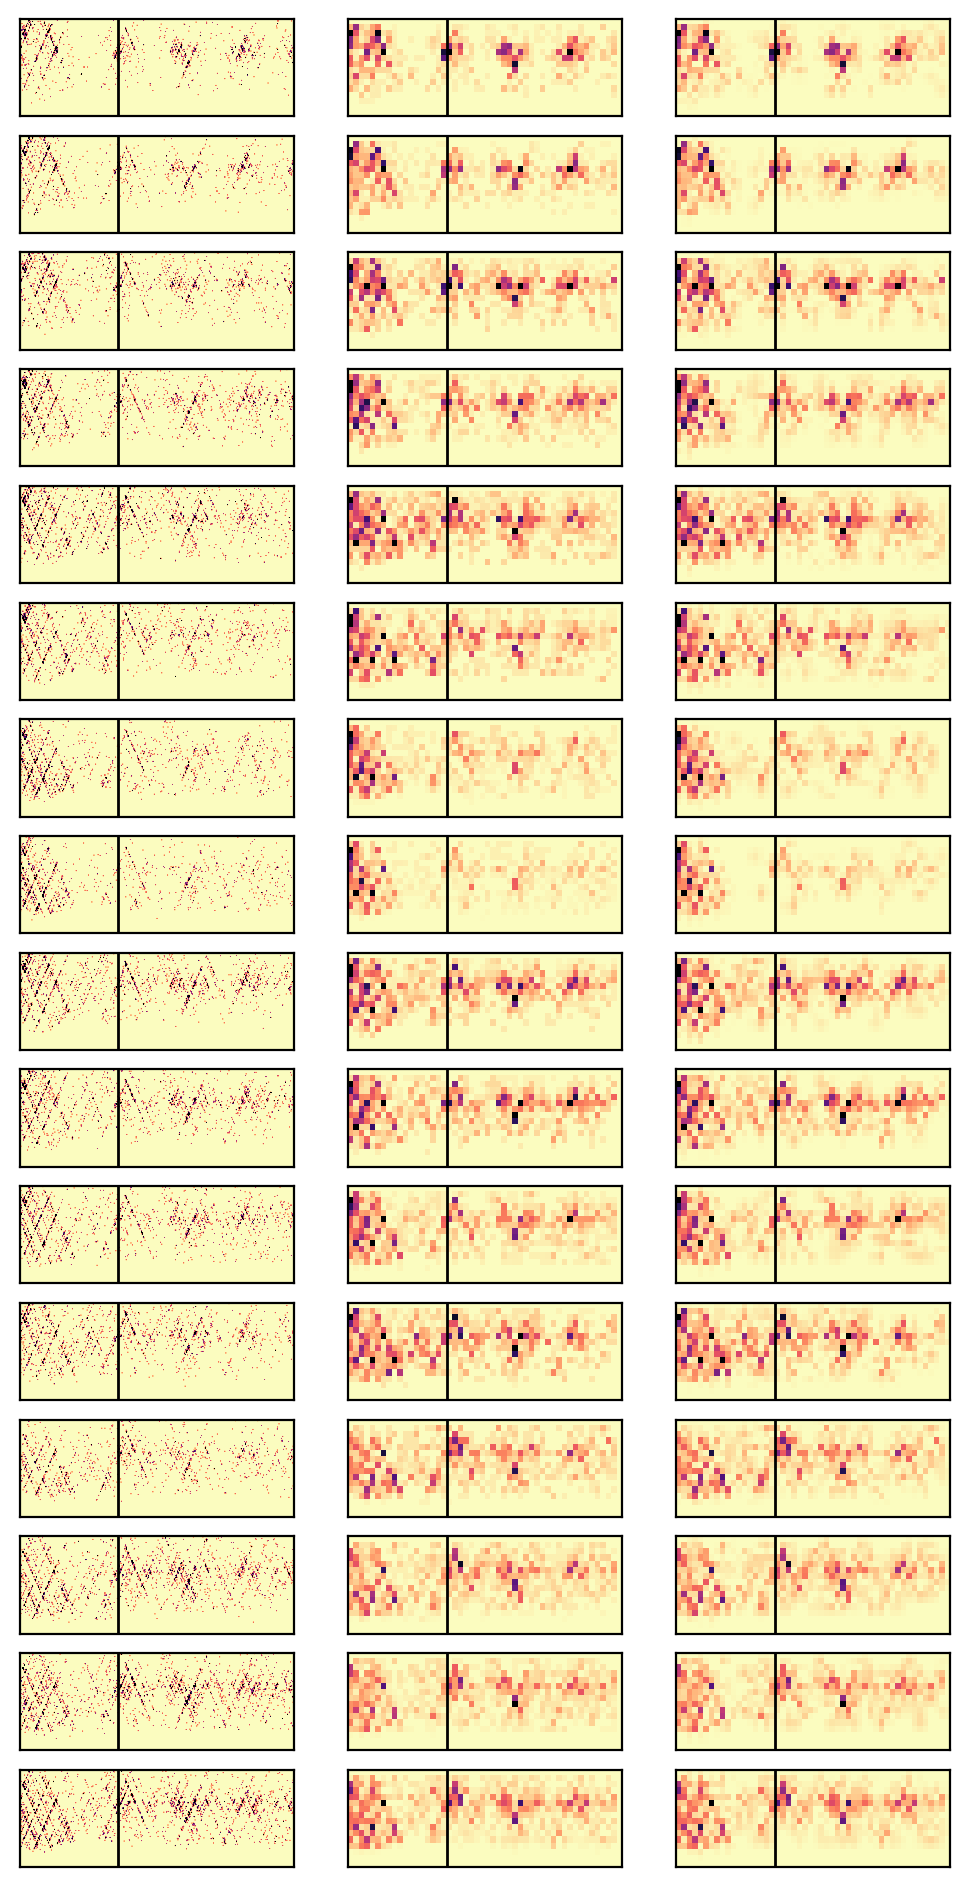

In [92]:
chromatin_model.plot_bin_comparison()

In [93]:
chromatin_model.gamma = 1e-05

In [94]:
from src.deconvolve_chromatin import deconvolve_chromatin_H
import cvxpy

chromatin_model.deconvolve(solver=cvxpy.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 15 04:25:02 PM: Your problem has 181600 variables, 1 constraints, and 0 parameters.
(CVXPY) Feb 15 04:25:02 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 15 04:25:02 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 15 04:25:02 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 15 04:25:02 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 15 04:25:02 PM: Compiling problem (target solver=MOSEK).

(CVXPY) Feb 15 04:26:14 PM: 26  1.7e-04  3.5e-04  1.2e-05  4.45e-01   6.399680699e+03   6.399680595e+03   1.7e-04  26.77 
(CVXPY) Feb 15 04:26:14 PM: 27  1.2e-04  2.4e-04  7.6e-06  4.62e-01   6.367756766e+03   6.367756591e+03   1.2e-04  27.24 
(CVXPY) Feb 15 04:26:15 PM: 28  1.1e-04  2.1e-04  6.7e-06  4.98e-01   6.359265129e+03   6.359264941e+03   1.1e-04  27.61 
(CVXPY) Feb 15 04:26:15 PM: 29  8.9e-05  1.8e-04  5.3e-06  5.06e-01   6.345832868e+03   6.345832664e+03   8.9e-05  27.97 
(CVXPY) Feb 15 04:26:15 PM: 30  6.5e-05  1.3e-04  3.6e-06  5.19e-01   6.325140204e+03   6.325139987e+03   6.5e-05  28.36 
(CVXPY) Feb 15 04:26:16 PM: Optimizer terminated. Time: 29.08   
(CVXPY) Feb 15 04:26:16 PM: 
(CVXPY) Feb 15 04:26:16 PM: 
(CVXPY) Feb 15 04:26:16 PM: Interior-point solution summary
(CVXPY) Feb 15 04:26:16 PM:   Problem status  : PRIMAL_AND_DUAL_FEASIBLE
(CVXPY) Feb 15 04:26:16 PM:   Solution status : OPTIMAL
(CVXPY) Feb 15 04:26:16 PM:   Primal.  obj: 6.3251402045e+03    nrm: 1e+04    

In [95]:
from src.model import Model
ge1_model = Model(config1, gene_name)

In [96]:
ge1_model.deconvolve_find_optimal_gamma()

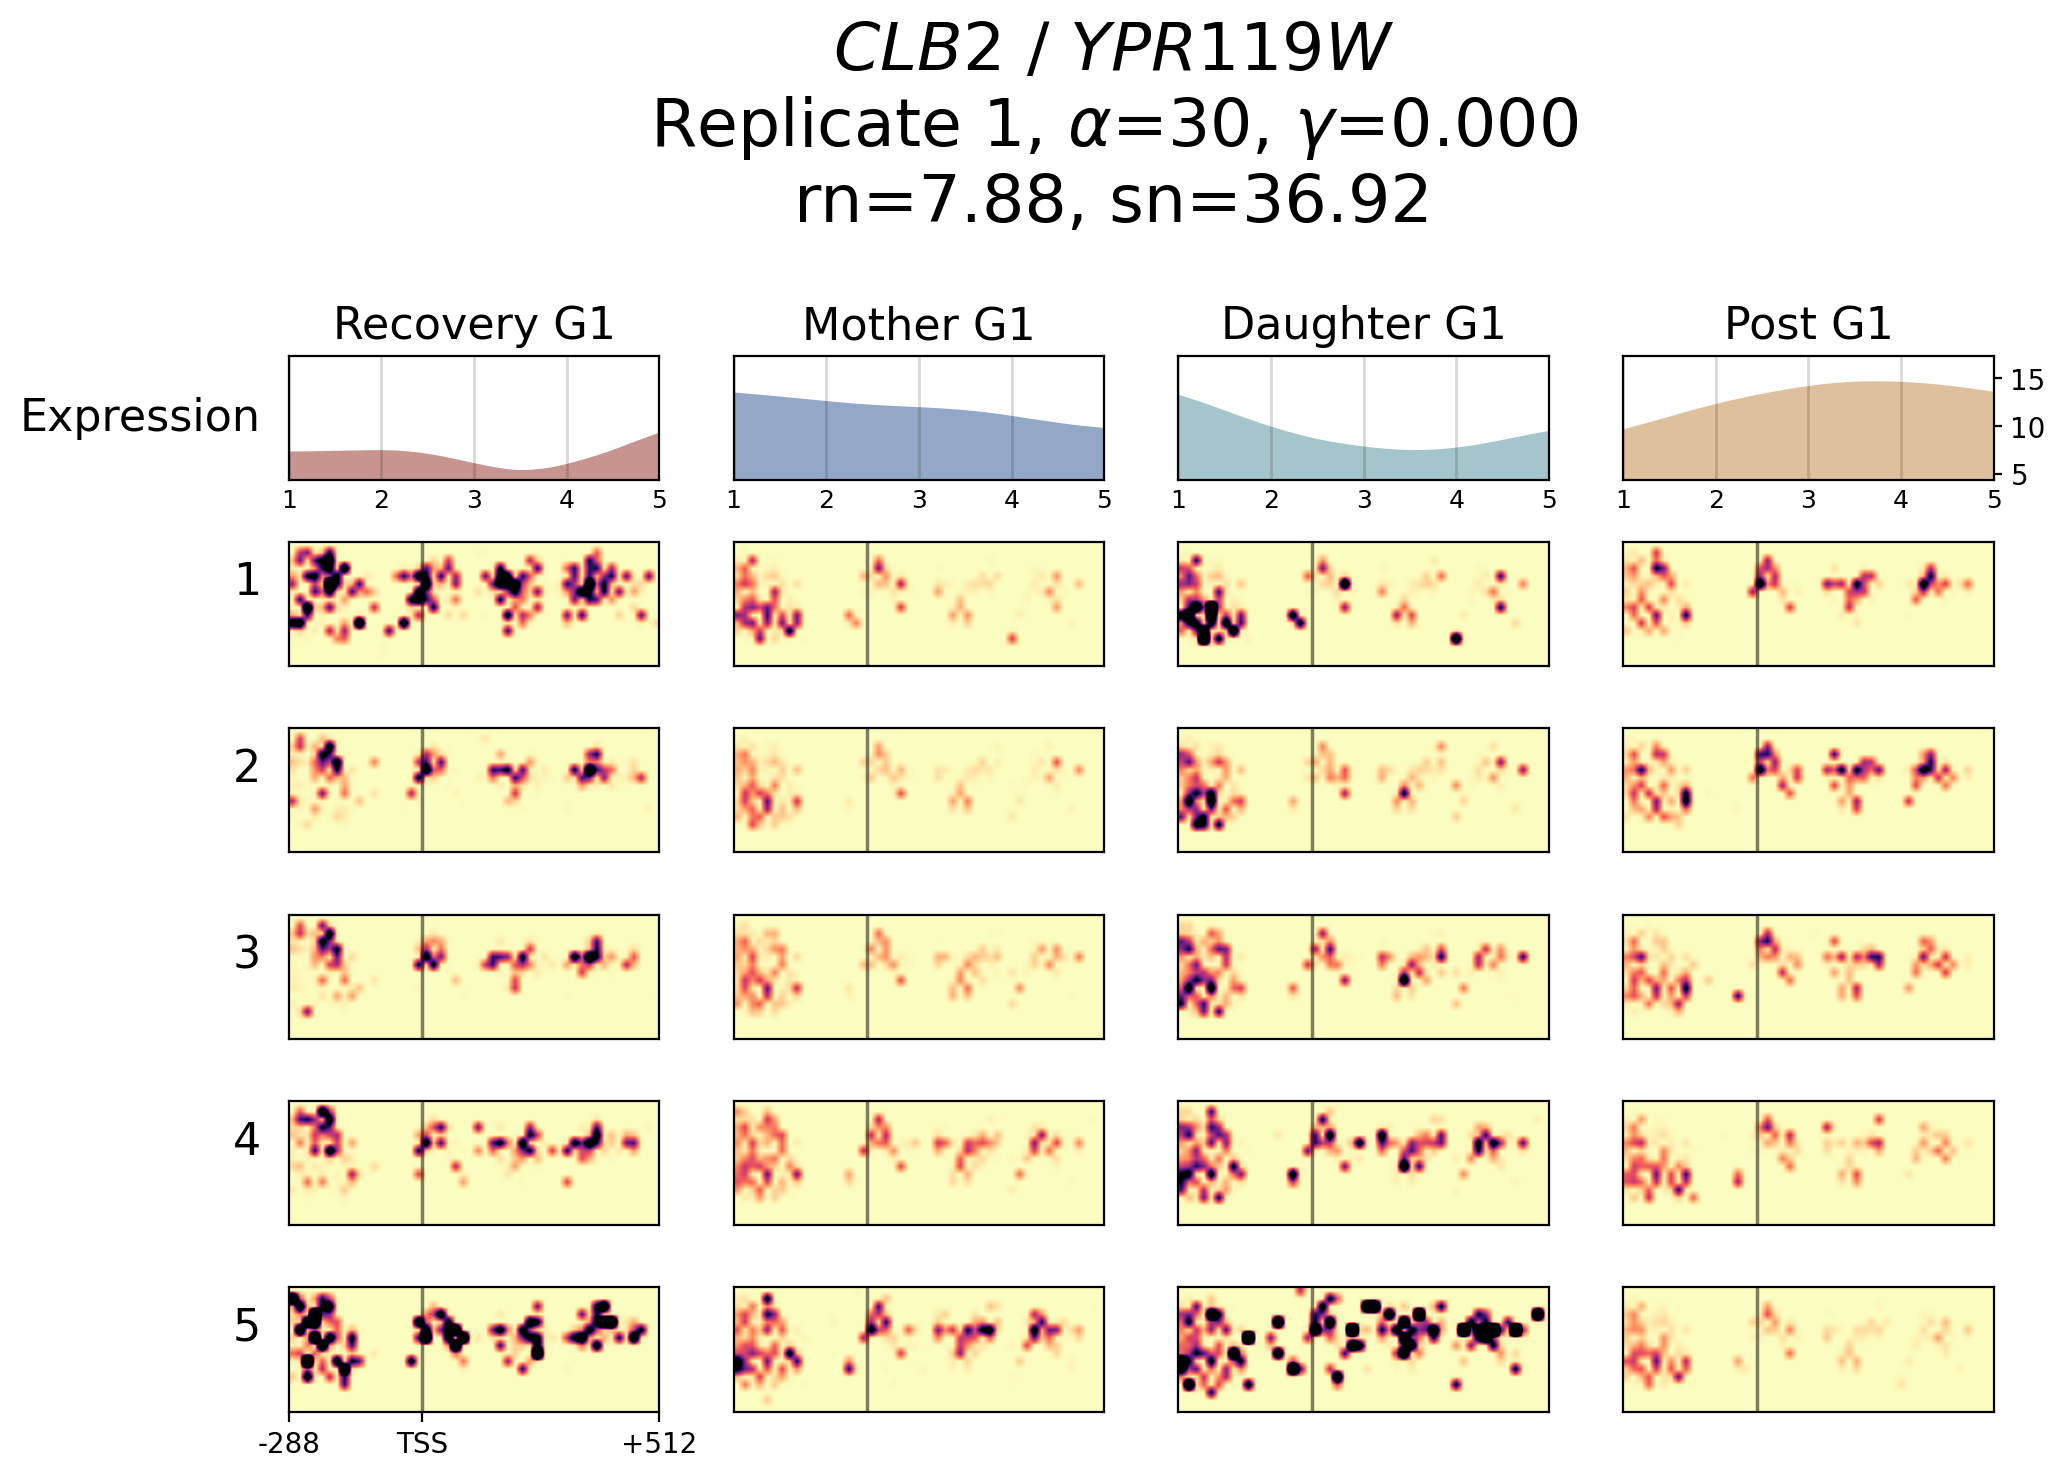

In [99]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge1_model, 
    vmax=10, smooth=True)

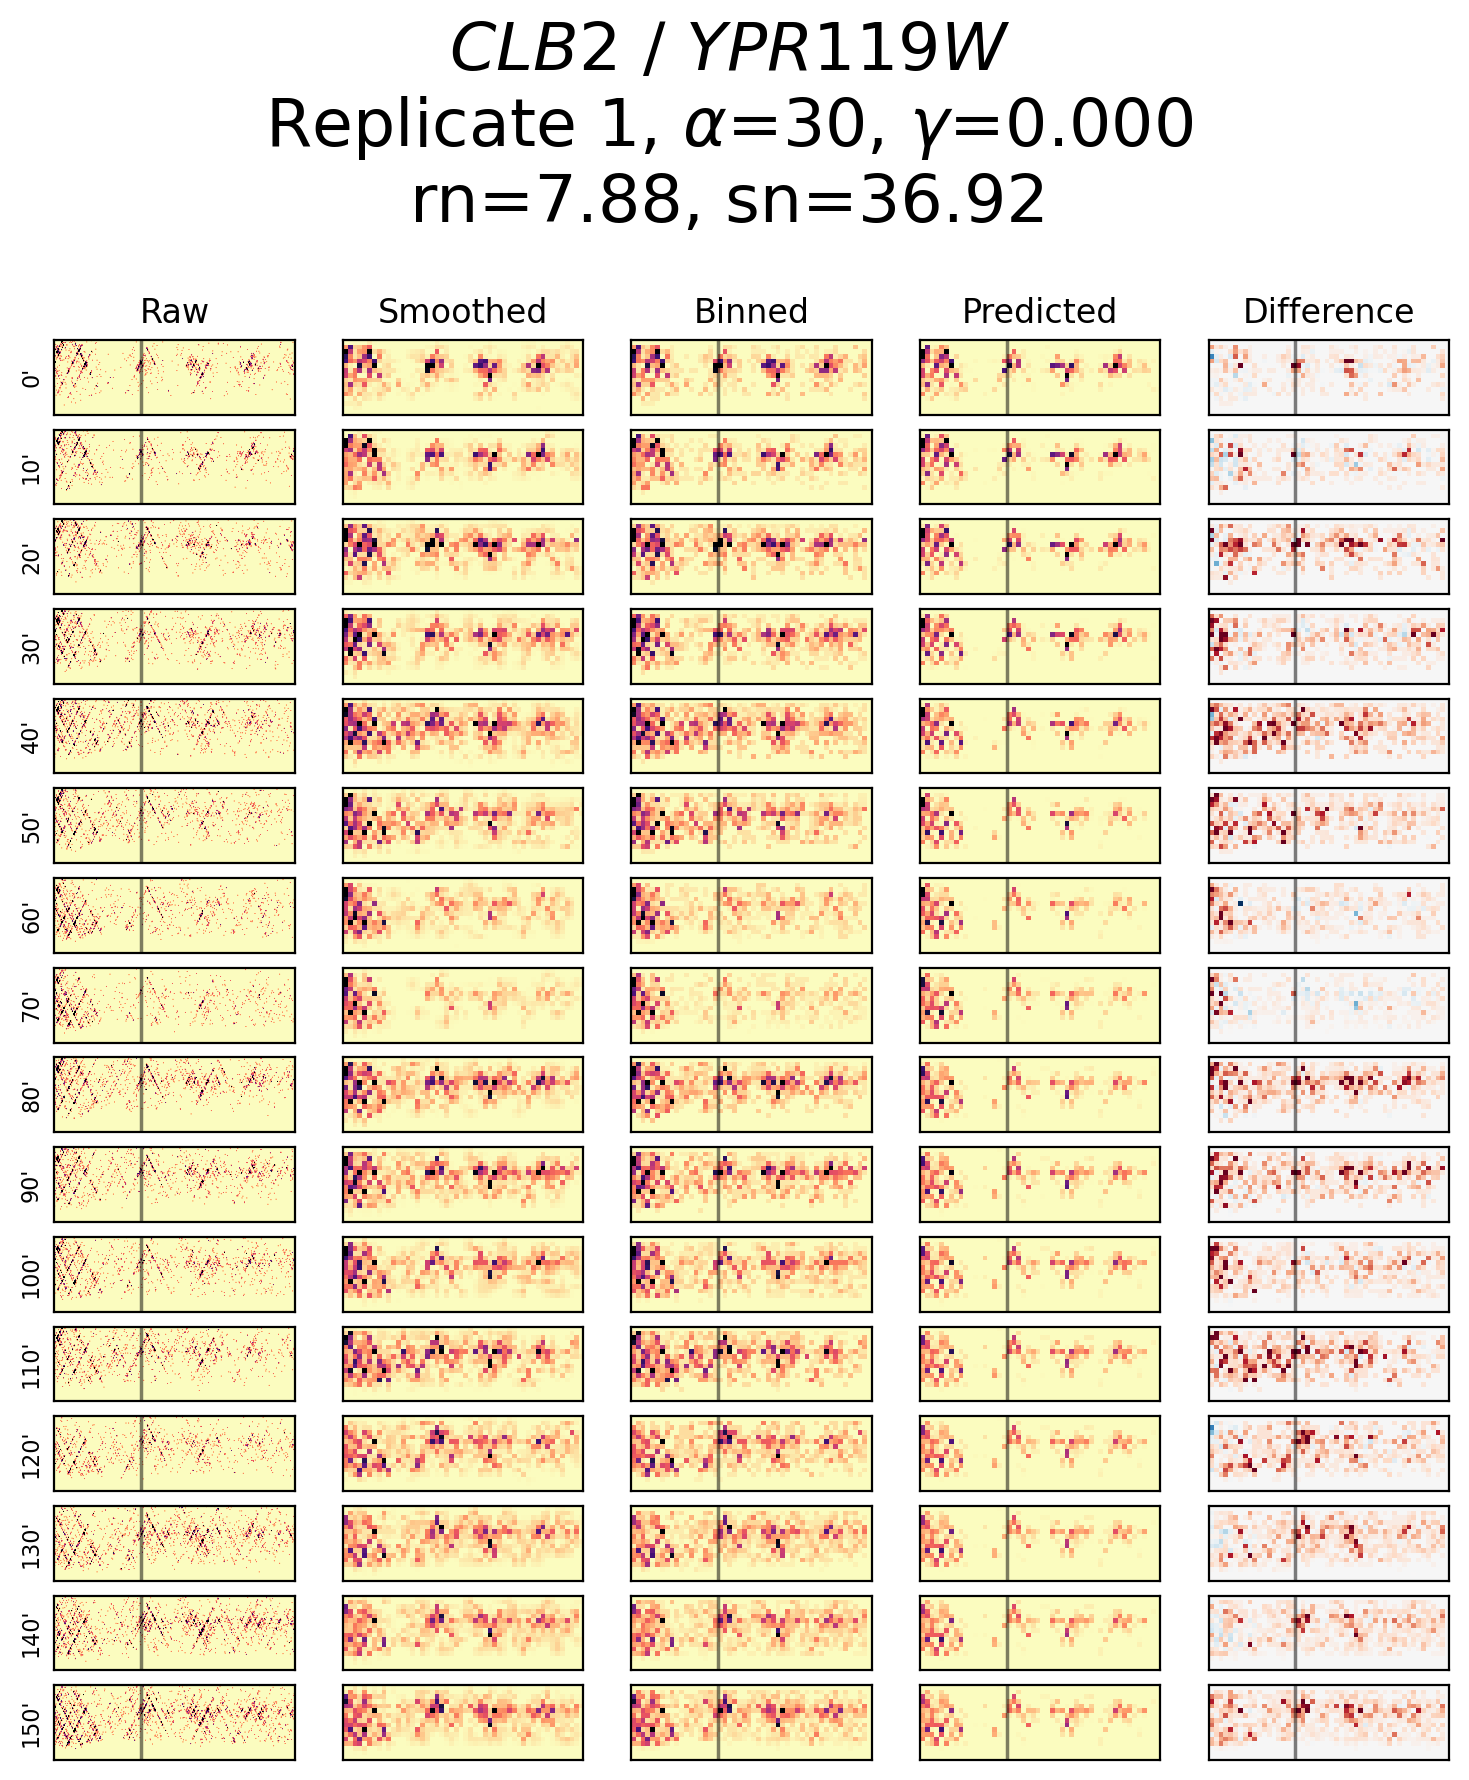

In [98]:
fig = chromatin_model.plot_prediction_comparison()